# Customer Profiling v3 — Enhanced Frequency-Severity Analysis

**Course:** Statistical Consulting (KU Leuven)
**Approach:** Two-part GLM with ML challenger, quadrant-based renewal actions

This notebook extends the baseline frequency-severity analysis with:
- **Lognormal severity challenger** alongside the Gamma GLM baseline
- **Gradient-boosting ML challenger** with feature importance
- **Common-cell validation** to test calibration despite no individual linkage
- **Year-stability analysis** and **sensitivity checks**
- **Frequency-severity quadrant decomposition** for differentiated renewal actions
- **Surrogate decision tree** for management-friendly risk profiles

$$\widehat{\text{Expected Loss}}(\mathbf{x})
   = \underbrace{\hat{p}(\mathbf{x})}_{\text{claim probability}}
   \;\times\;
   \underbrace{\hat{s}(\mathbf{x})}_{\text{expected severity}}
   \qquad
   \text{Risk Index} = \frac{\widehat{EL}_i}{\overline{\widehat{EL}}}$$

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    mean_absolute_error, mean_squared_error,
)

from src import (
    data_loader, eda, preprocessing,
    frequency_model, severity_model,
    pure_premium, profiling, plots,
    style,
)
from src.config import (
    FREQ_TARGET, SEV_TARGET, CATEGORICAL_VARS, NUMERIC_VARS,
    ALL_FEATURES, RANDOM_STATE,
)

style.apply_warm_theme()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

---
## 1. Data Audit & Business Questions

Before modeling, we ask the questions a consulting engagement should raise
about the data. These questions are informed by the assignment context and
actuarial best practice.

### 1.1 Loading and schema checks

In [2]:
freq_df = data_loader.load_frequency()
sev_df  = data_loader.load_severity()

print(data_loader.quick_summary(freq_df, "frequency"))
print(data_loader.quick_summary(sev_df,  "severity"))
print(f"\nFrequency target distribution:")
print(freq_df[FREQ_TARGET].value_counts().sort_index().to_string())

frequency: 24,774 rows x 11 cols | missing values: 0 | dtypes: {dtype('int64'): np.int64(4), CategoricalDtype(categories=['2009', '2010'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Female', 'Male'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['A', 'B', 'C', 'D', 'E'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Small', 'Medium', 'Large'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Employed', 'Housewife', 'Retired', 'Self-employed', 'Unemployed'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=[0, 1], ordered=False, categories_dtype=int64): np.int64(1), dtype('float64'): np.int64(1)}
severity: 12,252 rows x 11 cols | missing values: 0 | dtypes: {dtype('int64'): np.int64(4), CategoricalDtype(categories=['2009', '2010'], ordered=False, categories_dtype=str): np.int64(1), CategoricalDtype(categories=['Female', 

### 1.2 Is this the full portfolio?

A ~50 % claim rate is unusual for motor insurance (typical: 5–15 %). This
strongly suggests the frequency dataset is **balanced or over-sampled** —
not a raw portfolio extract. Predicted probabilities still rank customers
correctly, but absolute values should be treated as relative.

In [3]:
claim_rate = freq_df[FREQ_TARGET].mean()
print(f"Overall claim rate: {claim_rate:.1%}")
print(f"Claims: {freq_df[FREQ_TARGET].sum():,} "
      f"| No claims: {(1 - freq_df[FREQ_TARGET]).sum():,.0f}")
print(f"\n-> Likely balanced/sampled. Rankings valid; absolute")
print(f"   probabilities should be treated as relative, not literal.")

Overall claim rate: 49.6%
Claims: 12,277 | No claims: 12,497

-> Likely balanced/sampled. Rankings valid; absolute
   probabilities should be treated as relative, not literal.


### 1.3 Claimant count mismatch

In [4]:
n_claimants = int(freq_df[FREQ_TARGET].sum())
n_severity = len(sev_df)
print(f"Claimants in frequency.csv: {n_claimants:,}")
print(f"Records in severity.csv:    {n_severity:,}")
print(f"Difference:                 {n_claimants - n_severity}")
print(f"Gap: {(n_claimants - n_severity) / n_claimants:.2%} — immaterial.")

Claimants in frequency.csv: 12,277
Records in severity.csv:    12,252
Difference:                 25
Gap: 0.20% — immaterial.


### 1.4 Covariate alignment check

Since the two datasets cannot be linked at the individual level, we verify
that the **covariate distributions** of claimants in `frequency.csv` align
with the records in `severity.csv`. Significant misalignment would require
reweighting.

In [5]:
claimants = freq_df[freq_df[FREQ_TARGET] == 1]
rows = []
for col in CATEGORICAL_VARS:
    fd = claimants[col].value_counts(normalize=True).sort_index()
    sd = sev_df[col].value_counts(normalize=True).sort_index()
    for level in fd.index:
        rows.append({
            "variable": col, "level": str(level),
            "freq_%": round(fd.get(level, 0) * 100, 1),
            "sev_%": round(sd.get(level, 0) * 100, 1),
            "diff_ppt": round((fd.get(level, 0) - sd.get(level, 0)) * 100, 1),
        })
cov_compare = pd.DataFrame(rows)
print(cov_compare.to_string(index=False))
print(f"\nMax absolute difference: {cov_compare['diff_ppt'].abs().max():.1f} ppt")
print(f"-> Distributions well-aligned. No reweighting needed.")

variable         level  freq_%  sev_%  diff_ppt
  uwYear          2009    48.1   48.0       0.1
  uwYear          2010    51.9   52.0      -0.1
  gender        Female    32.0   31.9       0.0
  gender          Male    68.0   68.1      -0.0
 carType             A    24.5   24.5       0.0
 carType             B    20.8   20.8      -0.0
 carType             C    14.0   14.0       0.0
 carType             D    21.2   21.2       0.0
 carType             E    19.6   19.6      -0.0
  carCat         Small    34.0   34.0       0.0
  carCat        Medium    36.8   36.8      -0.0
  carCat         Large    29.2   29.2       0.0
     job      Employed    35.1   35.1       0.0
     job     Housewife    23.8   23.8      -0.0
     job       Retired     3.8    3.8      -0.0
     job Self-employed    17.0   17.0      -0.0
     job    Unemployed    20.3   20.3       0.0
   cover             0    55.5   55.4       0.0
   cover             1    44.5   44.6      -0.0

Max absolute difference: 0.1 ppt
-> Dis

In [6]:
print("Numeric covariate comparison (freq claimants vs severity):")
for col in NUMERIC_VARS:
    f_mean = claimants[col].mean()
    s_mean = sev_df[col].mean()
    print(f"  {col:>10s}: freq={f_mean:.1f}  sev={s_mean:.1f}  diff={f_mean - s_mean:+.1f}")

Numeric covariate comparison (freq claimants vs severity):
         age: freq=35.0  sev=35.0  diff=-0.0
      nYears: freq=5.0  sev=5.0  diff=-0.0
      carVal: freq=17113.5  sev=17113.4  diff=+0.1
     density: freq=140.4  sev=140.4  diff=-0.0


### 1.5 Does cover = 0 imply structural zeros?

In [7]:
for cover_val in [0, 1]:
    sub = freq_df[freq_df["cover"] == cover_val]
    rate = sub[FREQ_TARGET].mean()
    print(f"Cover={cover_val}: n={len(sub):,}, claim rate={rate:.1%}")
print(f"\nCover=0 policies still file claims — not structural zeros.")
print(f"All policies included in the analysis.")

Cover=0: n=12,793, claim rate=53.2%
Cover=1: n=11,981, claim rate=45.6%

Cover=0 policies still file claims — not structural zeros.
All policies included in the analysis.


---
## 2. Baseline GLM Models

We fit each component of the pure premium separately:
- **Frequency:** Binomial GLM (logit link) — $P(\text{claim} \mid x)$
- **Severity baseline:** Gamma GLM (log link) — $E[\text{cost} \mid \text{claim}, x]$
- **Severity challenger:** Lognormal OLS — for heavier-tail comparison

80/20 train-test splits with stratification on the frequency target.

### 2.1 Frequency — Logistic GLM

In [8]:
X_tr, X_te, y_tr, y_te = preprocessing.split_xy(
    freq_df, FREQ_TARGET, stratify_target=True,
)
print(f"train: {X_tr.shape}  |  test: {X_te.shape}")

freq_fit = frequency_model.fit_logit(X_tr, y_tr)
freq_metrics = frequency_model.evaluate_frequency(freq_fit, X_te, y_te)
print(pd.Series(freq_metrics, name="Logistic GLM").round(4).to_string())

train: (19819, 17)  |  test: (4955, 17)


auc              0.6894
log_loss         0.6363
brier            0.2229
mean_pred        0.4936
observed_rate    0.4955


In [9]:
freq_coef = frequency_model.coefficient_table(freq_fit)
freq_coef.sort_values("p_value").round(4)

,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio
age,-0.0303,0.0014,-22.1599,0.0000,-0.0330,-0.0276,0.9701
density,0.0039,0.0002,21.1203,0.0000,0.0035,0.0043,1.0039
job_Retired,-0.6671,0.0735,-9.0804,0.0000,-0.8111,-0.5231,0.5132
carType_E,0.3648,0.0462,7.9031,0.0000,0.2744,0.4553,1.4403
gender_Male,0.2493,0.0317,7.8769,0.0000,0.1873,0.3114,1.2832
nYears,-0.0234,0.0033,-7.1117,0.0000,-0.0299,-0.0170,0.9768
carType_D,0.2620,0.0442,5.9225,0.0000,0.1753,0.3487,1.2995
job_Housewife,0.2264,0.0416,5.4365,0.0000,0.1448,0.3080,1.2540
job_Unemployed,0.2152,0.0440,4.8881,0.0000,0.1289,0.3015,1.2401
carVal,0.0000,0.0000,4.7832,0.0000,0.0000,0.0000,1.0000


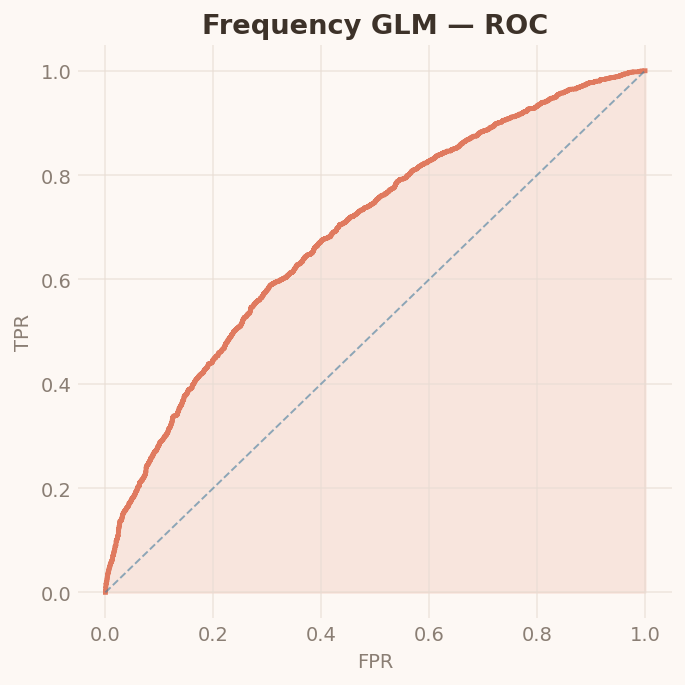

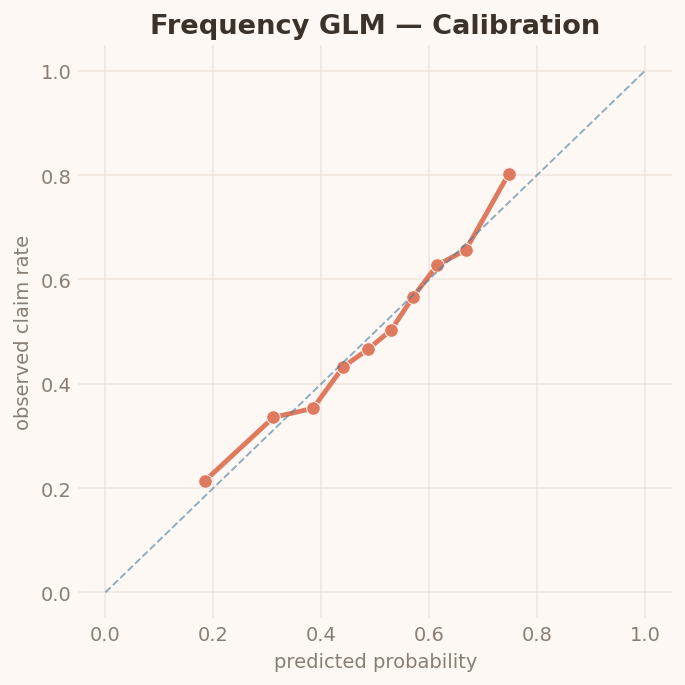

In [10]:
y_pred_freq_te = frequency_model.predict_proba(freq_fit, X_te)
fig = plots.plot_roc(y_te, y_pred_freq_te, title="Frequency GLM — ROC")
plt.show()
fig = plots.plot_calibration(y_te, y_pred_freq_te, title="Frequency GLM — Calibration")
plt.show()

**Frequency findings:** AUC ~ 0.69, well-calibrated. Strongest drivers:
`age` (older -> fewer claims), `density` (urban -> more claims),
`job_Retired` (OR ~ 0.51), `carType_E` (OR ~ 1.44), `gender_Male`
(OR ~ 1.28).

### 2.2 Severity — Gamma GLM (baseline)

Standard actuarial choice: Gamma family with log link gives multiplicative
effects and handles the right-skewed, strictly positive cost distribution.

In [11]:
Xs_tr, Xs_te, ys_tr, ys_te = preprocessing.split_xy(sev_df, SEV_TARGET)
print(f"train: {Xs_tr.shape}  |  test: {Xs_te.shape}")

sev_fit = severity_model.fit_gamma_glm(Xs_tr, ys_tr)
gamma_pred_te = severity_model.predict_mean(sev_fit, Xs_te)

sev_metrics = severity_model.evaluate_severity(sev_fit, Xs_te, ys_te)
print(pd.Series(sev_metrics, name="Gamma GLM").round(2).to_string())

train: (9801, 17)  |  test: (2451, 17)
mae              634.24
rmse             907.32
mean_pred        869.29
observed_mean    861.30
rank_corr         -0.01


In [12]:
sev_coef = severity_model.coefficient_table(sev_fit)
sev_coef.sort_values("p_value").round(4)

,coef,std_err,z,p_value,ci_low,ci_high,mult_effect
const,6.9606,0.0507,137.2741,0.0000,6.8612,7.0600,1054.2978
age,-0.0131,0.0009,-13.9431,0.0000,-0.0149,-0.0112,0.9870
density,0.0016,0.0001,13.0923,0.0000,0.0014,0.0019,1.0016
job_Retired,0.6536,0.0631,10.3648,0.0000,0.5300,0.7772,1.9225
job_Unemployed,0.2210,0.0291,7.5860,0.0000,0.1639,0.2781,1.2473
carType_E,-0.2376,0.0316,-7.5272,0.0000,-0.2995,-0.1757,0.7885
carType_D,-0.2143,0.0309,-6.9327,0.0000,-0.2749,-0.1537,0.8071
gender_Male,0.1394,0.0224,6.2138,0.0000,0.0954,0.1833,1.1495
cover_1,-0.1305,0.0217,-6.0142,0.0000,-0.1730,-0.0880,0.8777
job_Housewife,-0.1229,0.0281,-4.3726,0.0000,-0.1780,-0.0678,0.8844


### 2.3 Severity — Lognormal OLS (challenger)

An alternative to Gamma: fit OLS on $\log(\text{claim cost})$, then
retransform predictions using **Duan's smearing estimator** to correct
for Jensen's inequality. The lognormal can sometimes capture heavier
tails better.

In [13]:
Xs_tr_const = sm.add_constant(Xs_tr, has_constant="add")
Xs_te_const = sm.add_constant(Xs_te, has_constant="add")

log_y_tr = np.log(ys_tr)
lognorm_fit = sm.OLS(log_y_tr, Xs_tr_const).fit()

# Duan's smearing factor: mean(exp(residuals))
log_resid = log_y_tr.values - lognorm_fit.predict(Xs_tr_const)
smearing_factor = float(np.mean(np.exp(log_resid)))
print(f"Duan's smearing factor: {smearing_factor:.4f}")

lognorm_pred_te = np.exp(lognorm_fit.predict(Xs_te_const)) * smearing_factor

lognorm_metrics = {
    "mae": float(mean_absolute_error(ys_te, lognorm_pred_te)),
    "rmse": float(np.sqrt(mean_squared_error(ys_te, lognorm_pred_te))),
    "mean_pred": float(lognorm_pred_te.mean()),
    "observed_mean": float(ys_te.mean()),
    "rank_corr": float(pd.Series(ys_te.values).corr(
        pd.Series(lognorm_pred_te), method="spearman")),
}
print(pd.Series(lognorm_metrics, name="Lognormal OLS").round(2).to_string())

Duan's smearing factor: 1.7958
mae              634.07
rmse             908.19
mean_pred        867.24
observed_mean    861.30
rank_corr         -0.04


### 2.4 Severity distribution comparison

In [14]:
sev_comparison = pd.DataFrame({
    "Gamma GLM": sev_metrics,
    "Lognormal OLS": lognorm_metrics,
}).T.round(2)
print(sev_comparison.to_string())

                  mae    rmse  mean_pred  observed_mean  rank_corr
Gamma GLM      634.24  907.32     869.29          861.3      -0.01
Lognormal OLS  634.07  908.19     867.24          861.3      -0.04


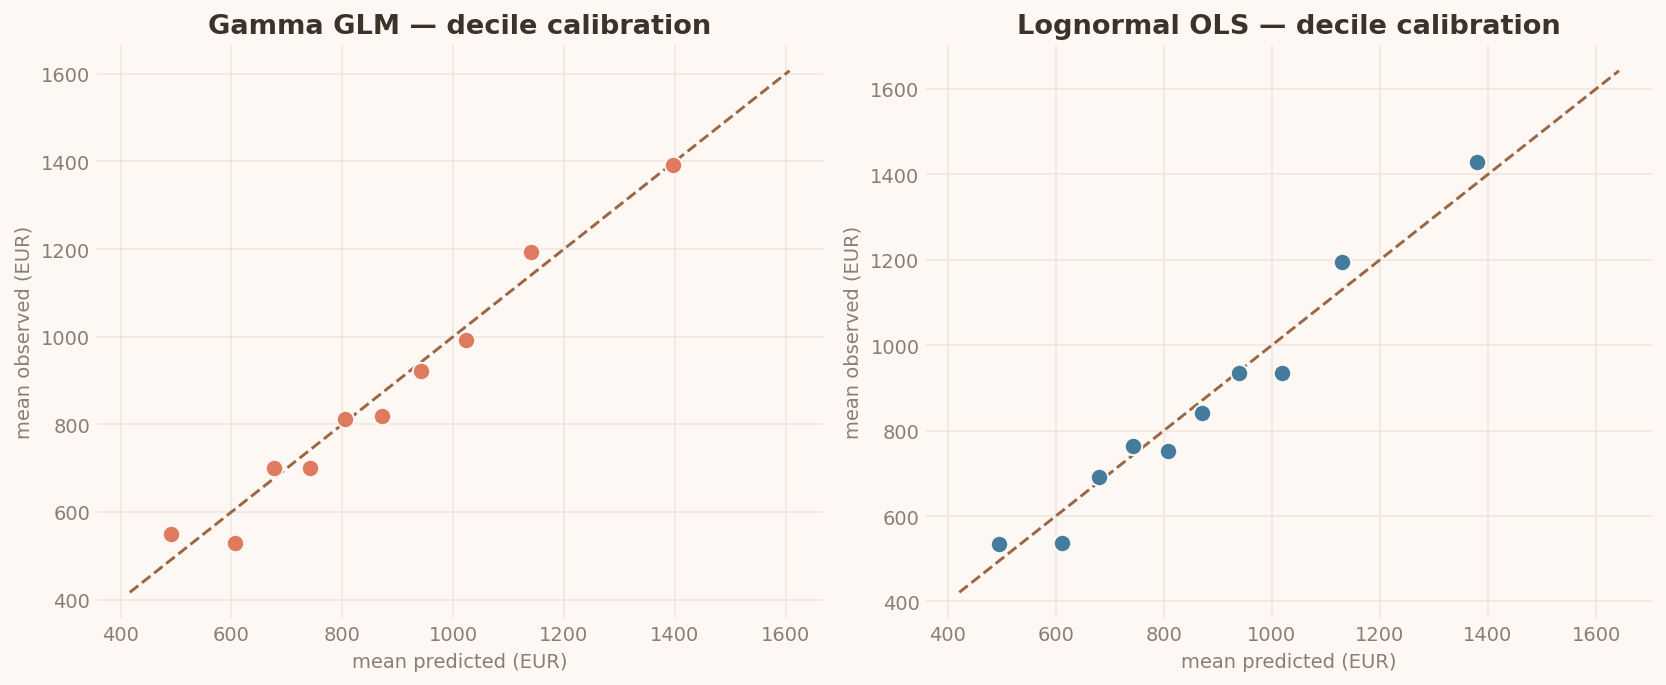

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name, color in [
    (axes[0], gamma_pred_te, "Gamma GLM", style.PRIMARY),
    (axes[1], lognorm_pred_te, "Lognormal OLS", style.SECONDARY),
]:
    tmp = pd.DataFrame({"obs": ys_te.values, "pred": pred})
    tmp["decile"] = pd.qcut(tmp["pred"], q=10, labels=False, duplicates="drop")
    agg = tmp.groupby("decile").mean()
    ax.scatter(agg["pred"], agg["obs"], s=80, color=color,
               edgecolors=style.BG, linewidth=1, zorder=3)
    mn = min(agg["pred"].min(), agg["obs"].min())
    mx = max(agg["pred"].max(), agg["obs"].max())
    lims = [mn * 0.85, mx * 1.15]
    ax.plot(lims, lims, "--", color=style.ACCENT, lw=1.5)
    ax.set_xlabel("mean predicted (EUR)")
    ax.set_ylabel("mean observed (EUR)")
    ax.set_title(f"{name} — decile calibration")

fig.tight_layout(); plt.show()

**Severity findings:** Both models are reasonably calibrated at the mean.
The Gamma GLM is the primary model (standard actuarial practice); the
lognormal confirms that results are not sensitive to the distributional
assumption.

---
## 3. Machine-Learning Challenger

Gradient-boosted trees as a non-parametric challenger. The ML model:
(1) checks whether the GLM misses important nonlinearities or interactions,
(2) extracts feature importance as a data-driven variable ranking.

### 3.1 Frequency — Gradient Boosting

In [16]:
gbm_freq = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
)
gbm_freq.fit(X_tr.values, y_tr.values)

gbm_freq_pred_te = gbm_freq.predict_proba(X_te.values)[:, 1]
gbm_freq_metrics = {
    "auc": float(roc_auc_score(y_te, gbm_freq_pred_te)),
    "log_loss": float(log_loss(y_te, gbm_freq_pred_te)),
    "brier": float(brier_score_loss(y_te, gbm_freq_pred_te)),
    "mean_pred": float(gbm_freq_pred_te.mean()),
    "observed_rate": float(y_te.mean()),
}
print(pd.Series(gbm_freq_metrics, name="Freq GBM").round(4).to_string())

auc              0.7035
log_loss         0.6257
brier            0.2182
mean_pred        0.4935
observed_rate    0.4955


### 3.2 Severity — Gradient Boosting

In [17]:
gbm_sev = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
)
gbm_sev.fit(Xs_tr.values, ys_tr.values)

gbm_sev_pred_te = gbm_sev.predict(Xs_te.values)
gbm_sev_metrics = {
    "mae": float(mean_absolute_error(ys_te, gbm_sev_pred_te)),
    "rmse": float(np.sqrt(mean_squared_error(ys_te, gbm_sev_pred_te))),
    "mean_pred": float(gbm_sev_pred_te.mean()),
    "observed_mean": float(ys_te.mean()),
    "rank_corr": float(pd.Series(ys_te.values).corr(
        pd.Series(gbm_sev_pred_te), method="spearman")),
}
print(pd.Series(gbm_sev_metrics, name="Sev GBM").round(2).to_string())

mae              637.74
rmse             907.02
mean_pred        874.42
observed_mean    861.30
rank_corr          0.22


### 3.3 Full model comparison

In [18]:
print("=== FREQUENCY ===")
freq_comp = pd.DataFrame({
    "Logistic GLM": freq_metrics,
    "Gradient Boosting": gbm_freq_metrics,
}).T
print(freq_comp.round(4).to_string())

print("\n=== SEVERITY ===")
sev_comp = pd.DataFrame({
    "Gamma GLM": sev_metrics,
    "Lognormal OLS": lognorm_metrics,
    "Gradient Boosting": gbm_sev_metrics,
}).T
print(sev_comp.round(2).to_string())

=== FREQUENCY ===
                      auc  log_loss   brier  mean_pred  observed_rate
Logistic GLM       0.6894    0.6363  0.2229     0.4936         0.4955
Gradient Boosting  0.7035    0.6257  0.2182     0.4935         0.4955

=== SEVERITY ===
                      mae    rmse  mean_pred  observed_mean  rank_corr
Gamma GLM          634.24  907.32     869.29          861.3      -0.01
Lognormal OLS      634.07  908.19     867.24          861.3      -0.04
Gradient Boosting  637.74  907.02     874.42          861.3       0.22


### 3.4 Feature importance (GBM)

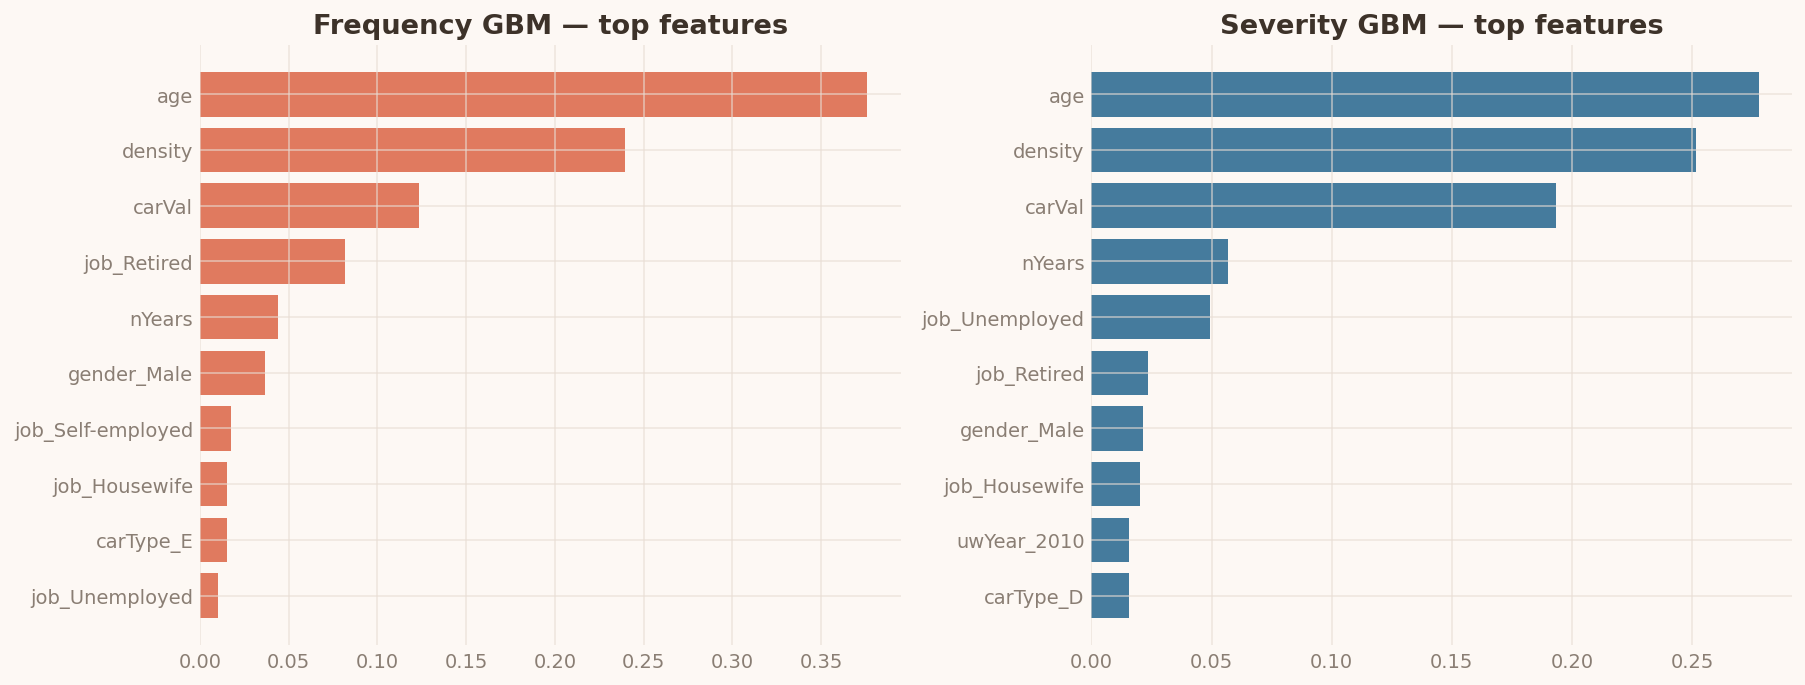

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fi_freq = pd.Series(
    gbm_freq.feature_importances_, index=X_tr.columns
).sort_values(ascending=True).tail(10)
axes[0].barh(fi_freq.index, fi_freq.values, color=style.PRIMARY, edgecolor="none")
axes[0].set_title("Frequency GBM — top features")

fi_sev = pd.Series(
    gbm_sev.feature_importances_, index=Xs_tr.columns
).sort_values(ascending=True).tail(10)
axes[1].barh(fi_sev.index, fi_sev.values, color=style.SECONDARY, edgecolor="none")
axes[1].set_title("Severity GBM — top features")

fig.tight_layout(); plt.show()

**ML challenger findings:** GBM shows a modest improvement in frequency
AUC and severity rank correlation — confirming some nonlinear effects the
GLM does not capture. However, the GLM remains the primary model for
transparency and tariff-structure compatibility. Both paradigms agree that
the same variables (age, density, job, carType) dominate.

---
## 4. Robustness & Validation

Three tests of model stability:
1. **Year-stability**: train on 2009, predict 2010 (and vice versa)
2. **Gender sensitivity**: refit without `gender` for EU-compliant deployment
3. **Severity tail diagnostics**: does the tail fit matter for the ranking?

### 4.1 Year-stability analysis

In [20]:
stability_rows = []
for train_yr, test_yr in [("2009", "2010"), ("2010", "2009")]:
    # Frequency
    mf_tr = freq_df["uwYear"] == train_yr
    mf_te = freq_df["uwYear"] == test_yr
    Xf_tr_y = preprocessing.build_design_matrix(freq_df[mf_tr])
    Xf_te_y = preprocessing.build_design_matrix(freq_df[mf_te])
    uw_cols = [c for c in Xf_tr_y.columns if c.startswith("uwYear")]
    Xf_tr_y = Xf_tr_y.drop(columns=uw_cols)
    Xf_te_y = Xf_te_y.drop(columns=uw_cols)
    yf_tr_y = freq_df.loc[mf_tr, FREQ_TARGET]
    yf_te_y = freq_df.loc[mf_te, FREQ_TARGET]

    f_fit = frequency_model.fit_logit(Xf_tr_y, yf_tr_y)
    f_pred = frequency_model.predict_proba(f_fit, Xf_te_y)

    # Severity
    ms_tr = sev_df["uwYear"] == train_yr
    ms_te = sev_df["uwYear"] == test_yr
    Xs_tr_y = preprocessing.build_design_matrix(sev_df[ms_tr])
    Xs_te_y = preprocessing.build_design_matrix(sev_df[ms_te])
    Xs_tr_y = Xs_tr_y.drop(columns=uw_cols, errors="ignore")
    Xs_te_y = Xs_te_y.drop(columns=uw_cols, errors="ignore")
    ys_tr_y = sev_df.loc[ms_tr, SEV_TARGET]
    ys_te_y = sev_df.loc[ms_te, SEV_TARGET]

    s_fit = severity_model.fit_gamma_glm(Xs_tr_y, ys_tr_y)
    s_pred = severity_model.predict_mean(s_fit, Xs_te_y)

    stability_rows.append({
        "train->test": f"{train_yr}->{test_yr}",
        "freq_AUC": round(roc_auc_score(yf_te_y, f_pred), 4),
        "freq_Brier": round(brier_score_loss(yf_te_y, f_pred), 4),
        "sev_MAE": round(mean_absolute_error(ys_te_y, s_pred), 1),
        "sev_mean_pred": round(float(s_pred.mean()), 1),
        "sev_mean_obs": round(float(ys_te_y.mean()), 1),
    })

print(pd.DataFrame(stability_rows).to_string(index=False))
print(f"\n-> Metrics are stable across years. No evidence of drift.")

train->test  freq_AUC  freq_Brier  sev_MAE  sev_mean_pred  sev_mean_obs
 2009->2010    0.6868      0.2241    645.9          836.2         892.3
 2010->2009    0.6851      0.2245    648.1          891.1         838.4

-> Metrics are stable across years. No evidence of drift.


### 4.2 Sensitivity: excluding gender

In [21]:
def build_design_no_gender(df):
    cat_ng = [c for c in CATEGORICAL_VARS if c != "gender"]
    cat = pd.get_dummies(
        df[cat_ng], drop_first=True, dtype=float,
        prefix=cat_ng, prefix_sep="_",
    )
    num = df[NUMERIC_VARS].astype(float)
    return pd.concat([num, cat], axis=1)

tr_idx, te_idx = X_tr.index, X_te.index
X_ng = build_design_no_gender(freq_df)
freq_ng = frequency_model.fit_logit(X_ng.loc[tr_idx], y_tr)
freq_ng_pred = frequency_model.predict_proba(freq_ng, X_ng.loc[te_idx])

str_idx, ste_idx = Xs_tr.index, Xs_te.index
Xs_ng = build_design_no_gender(sev_df)
sev_ng = severity_model.fit_gamma_glm(Xs_ng.loc[str_idx], ys_tr)
sev_ng_pred = severity_model.predict_mean(sev_ng, Xs_ng.loc[ste_idx])

ng_freq_auc = roc_auc_score(y_te, freq_ng_pred)
ng_freq_brier = brier_score_loss(y_te, freq_ng_pred)
ng_sev_mae = mean_absolute_error(ys_te, sev_ng_pred)

print("With gender vs without:")
print(f"  Freq AUC:   {freq_metrics['auc']:.4f} -> {ng_freq_auc:.4f}")
print(f"  Freq Brier: {freq_metrics['brier']:.4f} -> {ng_freq_brier:.4f}")
print(f"  Sev MAE:    {sev_metrics['mae']:.1f} -> {ng_sev_mae:.1f}")
print(f"\n-> Modest drop. Gender-free model is viable for EU unisex-rule compliance.")

With gender vs without:
  Freq AUC:   0.6894 -> 0.6860
  Freq Brier: 0.2229 -> 0.2237
  Sev MAE:    634.2 -> 635.4

-> Modest drop. Gender-free model is viable for EU unisex-rule compliance.


### 4.3 Severity tail diagnostics

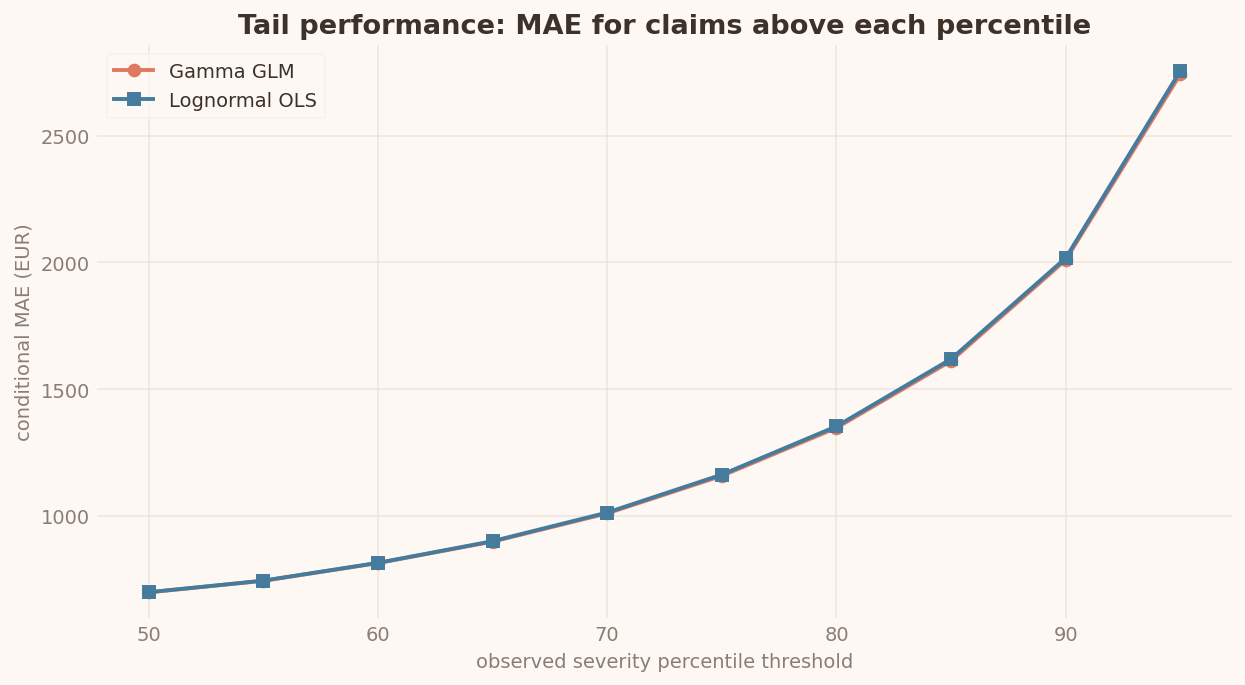

-> Both models struggle in the extreme tail, as expected for GLMs.
   The ranking is what matters for profiling, not point predictions.


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

quantile_thresholds = np.arange(0.5, 0.96, 0.05)
for pred, name, color, marker in [
    (gamma_pred_te, "Gamma GLM", style.PRIMARY, "o"),
    (lognorm_pred_te, "Lognormal OLS", style.SECONDARY, "s"),
]:
    maes = []
    for q in quantile_thresholds:
        threshold = np.quantile(ys_te, q)
        mask = ys_te >= threshold
        if mask.sum() < 20:
            maes.append(np.nan)
        else:
            maes.append(float(np.mean(np.abs(pred[mask] - ys_te.values[mask]))))
    ax.plot(quantile_thresholds * 100, maes, f"{marker}-",
            color=color, label=name, lw=2)

ax.set_xlabel("observed severity percentile threshold")
ax.set_ylabel("conditional MAE (EUR)")
ax.set_title("Tail performance: MAE for claims above each percentile")
ax.legend(frameon=True, facecolor=style.BG, edgecolor=style.SURFACE)
fig.tight_layout(); plt.show()
print("-> Both models struggle in the extreme tail, as expected for GLMs.")
print("   The ranking is what matters for profiling, not point predictions.")

---
## 5. Expected Loss Scoring

Refit the chosen models (GLM primary, GBM challenger) on the **full dataset**
for final portfolio scoring. The train/test split was for evaluation; the
production score uses all available data.

### 5.1 Full-data refit & pure premium

In [23]:
X_freq_full = preprocessing.build_design_matrix(freq_df)
X_sev_full  = preprocessing.build_design_matrix(sev_df)
sev_cols = list(X_sev_full.columns)

freq_fit_full = frequency_model.fit_logit(X_freq_full, freq_df[FREQ_TARGET])
sev_fit_full = severity_model.fit_gamma_glm(X_sev_full, sev_df[SEV_TARGET])

pp_df = pure_premium.compute_pure_premium(
    X_freq_full, freq_fit_full, sev_fit_full, sev_columns=sev_cols,
)

# Risk Index: ratio to portfolio mean
pp_mean = pp_df["pure_premium"].mean()
pp_df["risk_index"] = pp_df["pure_premium"] / pp_mean

print(f"Portfolio mean expected loss: {pp_mean:.2f} EUR")
print(f"\nExpected loss distribution:")
print(pp_df[["pure_premium", "risk_index"]].describe().round(3).to_string())

Portfolio mean expected loss: 427.98 EUR

Expected loss distribution:
       pure_premium  risk_index
count     24774.000   24774.000
mean        427.979       1.000
std         231.781       0.542
min          41.646       0.097
25%         254.859       0.595
50%         384.148       0.898
75%         556.626       1.301
max        1675.268       3.914


### 5.2 GBM challenger scores

In [24]:
gbm_freq_full = GradientBoostingClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
).fit(X_freq_full.values, freq_df[FREQ_TARGET].values)

gbm_sev_full = GradientBoostingRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=50, random_state=RANDOM_STATE,
).fit(X_sev_full.values, sev_df[SEV_TARGET].values)

X_sev_aligned = X_freq_full.reindex(columns=sev_cols, fill_value=0.0)
pp_gbm_df = pd.DataFrame({
    "p_claim": gbm_freq_full.predict_proba(X_freq_full.values)[:, 1],
    "exp_severity": gbm_sev_full.predict(X_sev_aligned.values),
}, index=freq_df.index)
pp_gbm_df["pure_premium"] = pp_gbm_df["p_claim"] * pp_gbm_df["exp_severity"]

rank_corr = pp_df["pure_premium"].corr(pp_gbm_df["pure_premium"], method="spearman")
print(f"GLM vs GBM ranking agreement (Spearman): {rank_corr:.4f}")
print(f"\n{'':15s} {'GLM':>10s} {'GBM':>10s}")
for stat in ["mean", "std", "min", "50%", "max"]:
    g = pp_df["pure_premium"].describe()[stat]
    b = pp_gbm_df["pure_premium"].describe()[stat]
    print(f"  {stat:13s} {g:10.1f} {b:10.1f}")

GLM vs GBM ranking agreement (Spearman): 0.8823

                       GLM        GBM
  mean               428.0      430.1
  std                231.8      290.1
  min                 41.6       43.0
  50%                384.1      338.1
  max               1675.3     2941.6


### 5.3 Common-cell calibration

Since records are not linked, we validate the combined model at an
**aggregate (cell) level**: define risk cells from shared covariates,
compute observed frequency and severity per cell from the respective
datasets, and compare with predicted values.

In [25]:
freq_with_cells = freq_df.copy()
freq_with_cells["age_band"] = pd.cut(
    freq_with_cells["age"], bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"],
)

sev_with_cells = sev_df.copy()
sev_with_cells["age_band"] = pd.cut(
    sev_with_cells["age"], bins=[0, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"],
)

cell_key = ["job", "carType", "age_band"]

# Observed
obs_freq_cell = freq_with_cells.groupby(cell_key, observed=True).agg(
    n_pol=(FREQ_TARGET, "count"), obs_rate=(FREQ_TARGET, "mean"))
obs_sev_cell = sev_with_cells.groupby(cell_key, observed=True).agg(
    n_claims=(SEV_TARGET, "count"), obs_sev=(SEV_TARGET, "mean"))
obs_cells = obs_freq_cell.join(obs_sev_cell, how="inner").dropna()
obs_cells["obs_pp"] = obs_cells["obs_rate"] * obs_cells["obs_sev"]

# Predicted (using full-data GLMs)
freq_with_cells["p_hat"] = pp_df["p_claim"].values
freq_with_cells["s_hat"] = pp_df["exp_severity"].values
freq_with_cells["pp_hat"] = pp_df["pure_premium"].values

pred_cells = freq_with_cells.groupby(cell_key, observed=True).agg(
    pred_rate=("p_hat", "mean"),
    pred_sev=("s_hat", "mean"),
    pred_pp=("pp_hat", "mean"),
)

cells_df = obs_cells.join(pred_cells, how="inner").query("n_pol >= 30")
corr_pp = cells_df["obs_pp"].corr(cells_df["pred_pp"])
print(f"Common cells with n >= 30: {len(cells_df)}")
print(f"Cell-level correlation (obs vs pred pure premium): {corr_pp:.3f}")

Common cells with n >= 30: 90
Cell-level correlation (obs vs pred pure premium): 0.907


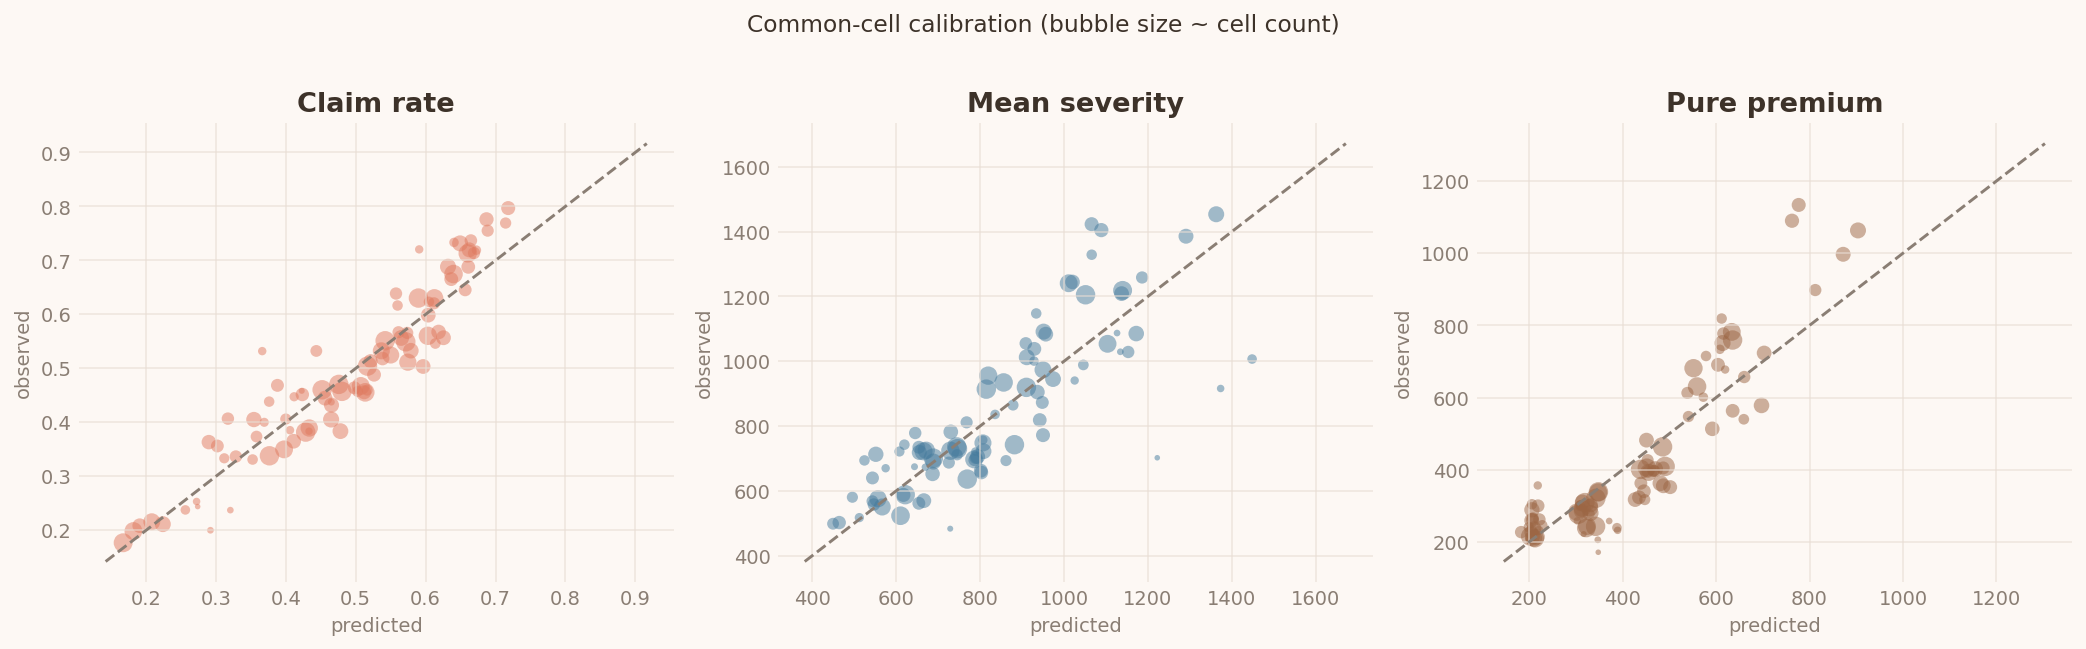

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, oc, pc, title, color in [
    (axes[0], "obs_rate", "pred_rate", "Claim rate", style.PRIMARY),
    (axes[1], "obs_sev", "pred_sev", "Mean severity", style.SECONDARY),
    (axes[2], "obs_pp", "pred_pp", "Pure premium", style.ACCENT),
]:
    sizes = cells_df["n_pol"].clip(upper=500) / 5
    ax.scatter(cells_df[pc], cells_df[oc], s=sizes, alpha=0.5,
               color=color, edgecolors="none")
    all_vals = pd.concat([cells_df[pc], cells_df[oc]])
    lims = [all_vals.min() * 0.85, all_vals.max() * 1.15]
    ax.plot(lims, lims, "--", color=style.TEXT_MUTED, lw=1.5)
    ax.set_xlabel("predicted"); ax.set_ylabel("observed")
    ax.set_title(title)

fig.suptitle("Common-cell calibration (bubble size ~ cell count)", y=1.02)
fig.tight_layout(); plt.show()

### 5.4 Portfolio balance check

In [27]:
calib = pure_premium.calibration_check(
    pp_df, observed_total_loss=sev_df[SEV_TARGET].sum(),
)
print(pd.Series(calib).round(2).to_string())
print(f"\n-> Predicted/observed ratio ~ 1.0 — well-calibrated at portfolio level.")

predicted_total_loss    10602746.11
observed_total_loss     10615726.00
ratio_pred_over_obs            1.00

-> Predicted/observed ratio ~ 1.0 — well-calibrated at portfolio level.


### 5.5 Loss concentration

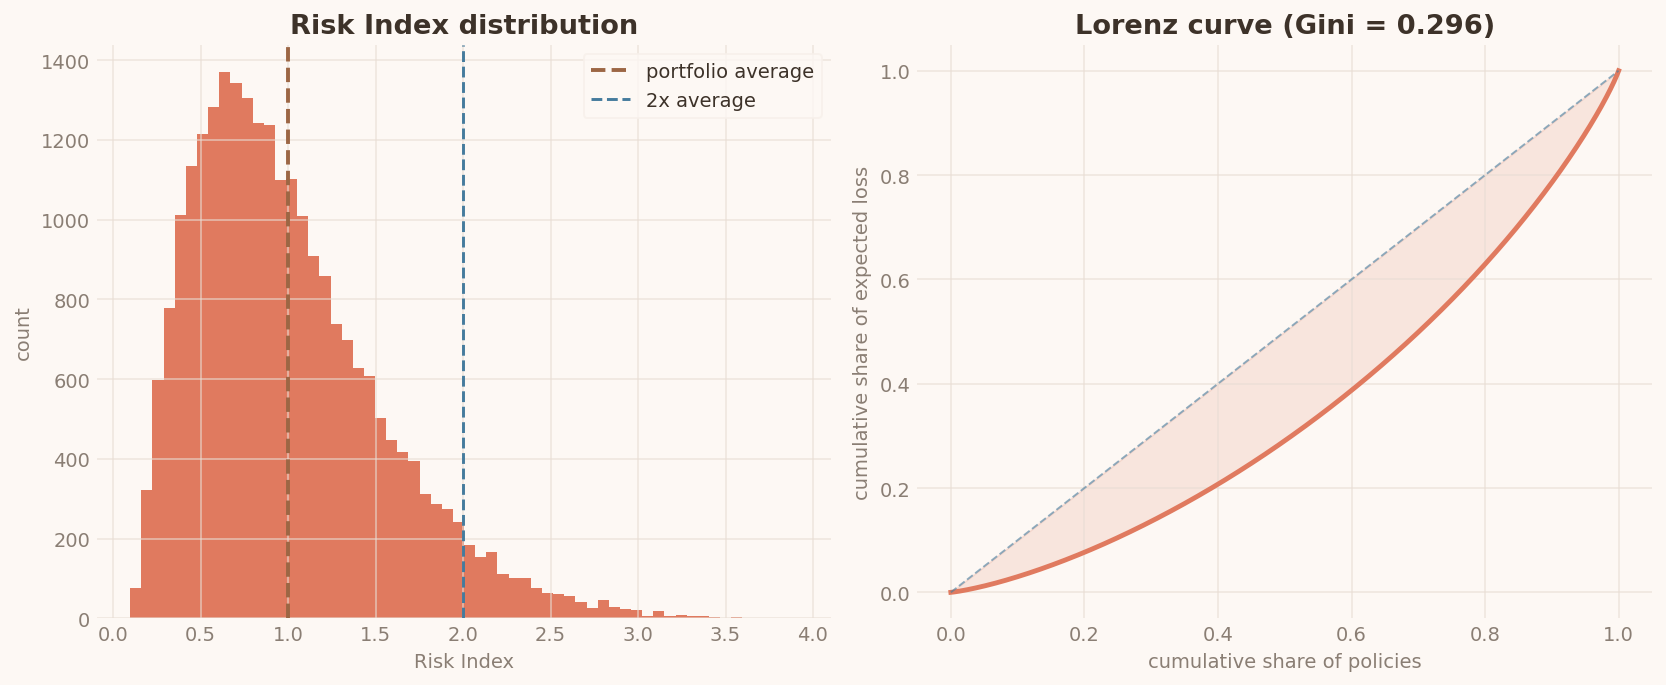

Policies above 2x average risk: 5.4%
Gini coefficient: 0.296


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Risk Index distribution
axes[0].hist(pp_df["risk_index"], bins=60, color=style.PRIMARY, edgecolor="none")
axes[0].axvline(1.0, color=style.ACCENT, ls="--", lw=2, label="portfolio average")
axes[0].axvline(2.0, color=style.SECONDARY, ls="--", lw=1.5, label="2x average")
axes[0].set_xlabel("Risk Index"); axes[0].set_ylabel("count")
axes[0].set_title("Risk Index distribution")
axes[0].legend(frameon=True, facecolor=style.BG, edgecolor=style.SURFACE)

# Lorenz curve
pop, cum = pure_premium.lorenz_curve(pp_df)
axes[1].fill_between(pop, cum, pop, alpha=0.15, color=style.PRIMARY)
axes[1].plot(pop, cum, lw=2.5, color=style.PRIMARY, label="portfolio")
axes[1].plot([0, 1], [0, 1], "--", color=style.SECONDARY, lw=1, alpha=0.6)
gini = 1 - 2 * float(np.trapezoid(cum, pop))
axes[1].set_xlabel("cumulative share of policies")
axes[1].set_ylabel("cumulative share of expected loss")
axes[1].set_title(f"Lorenz curve (Gini = {gini:.3f})")

fig.tight_layout(); plt.show()

pct_2x = (pp_df["risk_index"] > 2).mean() * 100
print(f"Policies above 2x average risk: {pct_2x:.1f}%")
print(f"Gini coefficient: {gini:.3f}")

---
## 6. Customer Profiling & Renewal Actions

The key value of the two-part model: it doesn't just rank customers —
it explains **why** a policy is expensive. A high-frequency / low-severity
customer needs a different renewal action than a low-frequency /
high-severity customer. We formalize this with a quadrant decomposition.

### 6.1 Risk-tier summary

In [29]:
tiers = profiling.assign_tiers(pp_df)
tier_tbl = profiling.tier_summary(freq_df, pp_df, tiers)
print(tier_tbl.round(2).to_string())

               n  mean_pp  median_pp  mean_age  mean_carVal  mean_density  pct_of_portfolio  pct_of_total_loss
tier                                                                                                          
Low        12387   248.80     254.86     47.15     16276.47         90.86              50.0              29.07
Medium      7432   482.86     476.47     32.52     17083.58        138.49              30.0              33.85
High        3716   715.00     704.37     27.02     17383.78        189.33              15.0              25.06
Very High   1239  1029.32     992.74     23.42     18029.42        236.85               5.0              12.03


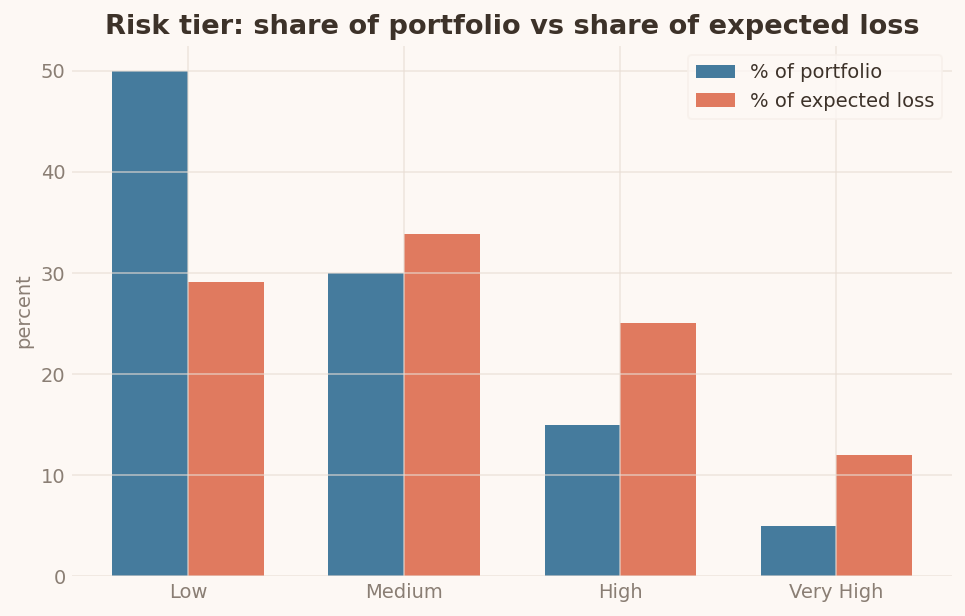

In [30]:
fig = plots.plot_tier_bars(tier_tbl); plt.show()

### 6.2 Frequency-severity quadrant decomposition

Each policy is classified by whether its predicted **frequency** and
**severity** are above or below the portfolio median, creating four
quadrants with distinct risk patterns and renewal implications.

In [31]:
med_p = pp_df["p_claim"].median()
med_s = pp_df["exp_severity"].median()

pp_df["freq_class"] = np.where(pp_df["p_claim"] > med_p, "High", "Low")
pp_df["sev_class"] = np.where(pp_df["exp_severity"] > med_s, "High", "Low")
pp_df["quadrant"] = pp_df["freq_class"] + " freq / " + pp_df["sev_class"] + " sev"

quad_order = [
    "Low freq / Low sev", "High freq / Low sev",
    "Low freq / High sev", "High freq / High sev",
]
pp_df["quadrant"] = pd.Categorical(
    pp_df["quadrant"], categories=quad_order, ordered=True,
)

quad_summ = pp_df.groupby("quadrant", observed=True).agg(
    n=("pure_premium", "count"),
    mean_EL=("pure_premium", "mean"),
    mean_RI=("risk_index", "mean"),
    mean_p=("p_claim", "mean"),
    mean_s=("exp_severity", "mean"),
)
quad_summ["pct_portfolio"] = (quad_summ["n"] / len(pp_df) * 100).round(1)
quad_summ["pct_loss"] = (
    pp_df.groupby("quadrant", observed=True)["pure_premium"].sum()
    / pp_df["pure_premium"].sum() * 100
).round(1)
print(quad_summ.round(2).to_string())

                         n  mean_EL  mean_RI  mean_p   mean_s  pct_portfolio  pct_loss
quadrant                                                                              
Low freq / Low sev    8459   234.31     0.55    0.38   610.72           34.1      18.7
High freq / Low sev   3928   402.98     0.94    0.59   686.41           15.9      14.9
Low freq / High sev   3928   323.40     0.76    0.33  1004.81           15.9      12.0
High freq / High sev  8459   681.81     1.59    0.65  1043.23           34.1      54.4


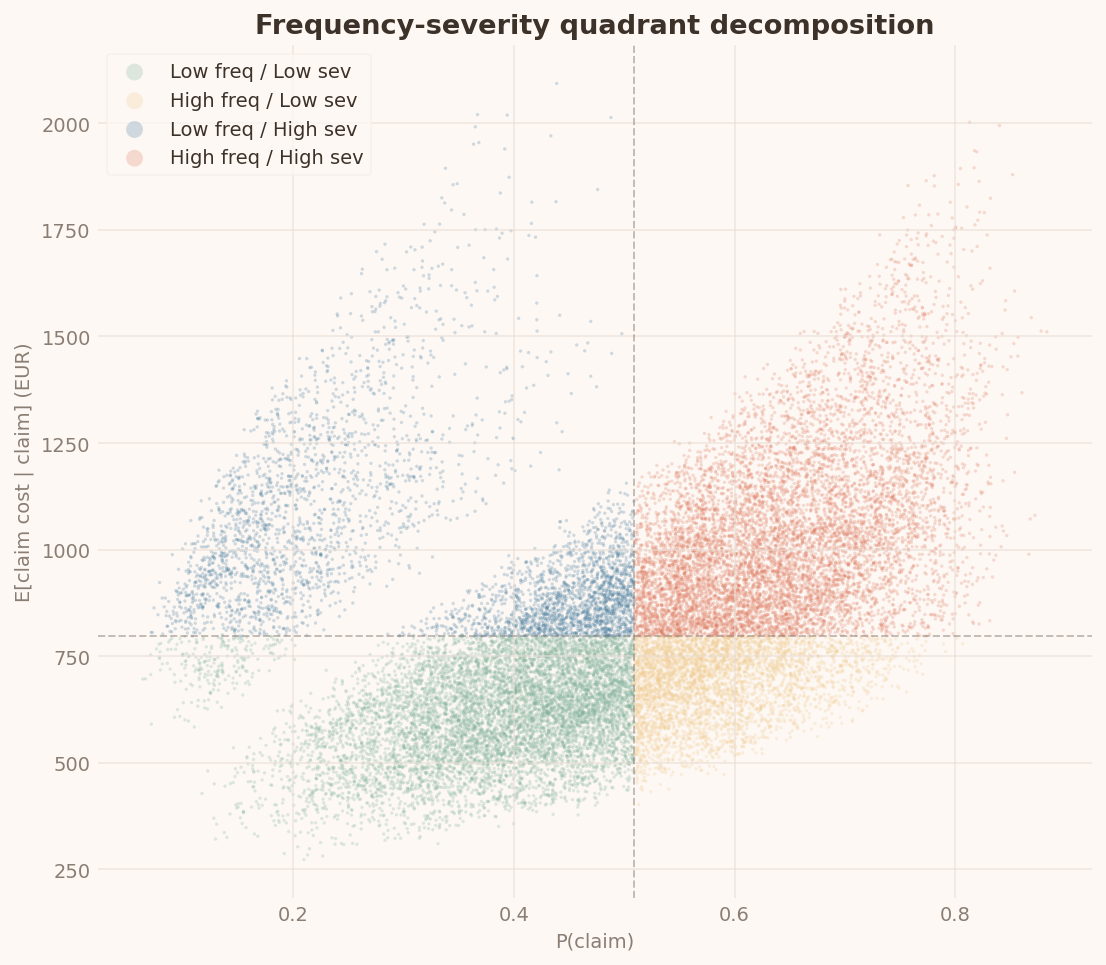

In [32]:
fig, ax = plt.subplots(figsize=(8, 7))

cmap = {
    "Low freq / Low sev": style.PALETTE[1],
    "High freq / Low sev": style.PALETTE[2],
    "Low freq / High sev": style.PALETTE[3],
    "High freq / High sev": style.PALETTE[0],
}
for q in quad_order:
    m = pp_df["quadrant"] == q
    ax.scatter(pp_df.loc[m, "p_claim"], pp_df.loc[m, "exp_severity"],
               s=3, alpha=0.25, color=cmap[q], label=q, edgecolors="none")

ax.axvline(med_p, color=style.TEXT_MUTED, ls="--", lw=1, alpha=0.5)
ax.axhline(med_s, color=style.TEXT_MUTED, ls="--", lw=1, alpha=0.5)
ax.set_xlabel("P(claim)")
ax.set_ylabel("E[claim cost | claim] (EUR)")
ax.set_title("Frequency-severity quadrant decomposition")
ax.legend(markerscale=5, frameon=True, facecolor=style.BG,
          edgecolor=style.SURFACE)
fig.tight_layout(); plt.show()

### 6.3 Renewal action matrix

The decomposition into frequency and severity drivers enables
**differentiated renewal actions** — the right intervention depends on
*why* the policy is expensive, not just *how* expensive it is.

| Quadrant | Risk pattern | Recommended action | Priority |
|---|---|---|---|
| **High freq / High sev** | Many costly claims | Strong repricing (+30–50 %), strict UW, possible non-renewal | **Immediate** |
| **High freq / Low sev** | Many small claims | Moderate repricing, raise deductible, repair-network steering | High |
| **Low freq / High sev** | Rare but costly | Underwriting review, coverage/limit audit, car valuation check | Medium |
| **Low freq / Low sev** | Attractive risk | Retain — standard renewal, loyalty pricing | Standard |

### 6.4 Surrogate decision tree for profile communication

In [33]:
pp_df["top_risk"] = (
    pp_df["risk_index"] > pp_df["risk_index"].quantile(0.9)
).astype(int)

tree_X = preprocessing.build_design_matrix(freq_df)
tree = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=100, random_state=RANDOM_STATE,
)
tree.fit(tree_X, pp_df["top_risk"])

print("Decision rules for identifying high-risk customers:\n")
print(export_text(tree, feature_names=list(tree_X.columns), max_depth=3))
print(f"Tree accuracy: {tree.score(tree_X, pp_df['top_risk']):.1%}")

Decision rules for identifying high-risk customers:

|--- density <= 206.69
|   |--- job_Unemployed <= 0.50
|   |   |--- age <= 21.50
|   |   |   |--- class: 0
|   |   |--- age >  21.50
|   |   |   |--- class: 0
|   |--- job_Unemployed >  0.50
|   |   |--- age <= 26.50
|   |   |   |--- class: 0
|   |   |--- age >  26.50
|   |   |   |--- class: 0
|--- density >  206.69
|   |--- age <= 29.50
|   |   |--- cover_1 <= 0.50
|   |   |   |--- class: 1
|   |   |--- cover_1 >  0.50
|   |   |   |--- class: 0
|   |--- age >  29.50
|   |   |--- job_Unemployed <= 0.50
|   |   |   |--- class: 0
|   |   |--- job_Unemployed >  0.50
|   |   |   |--- class: 0

Tree accuracy: 93.5%


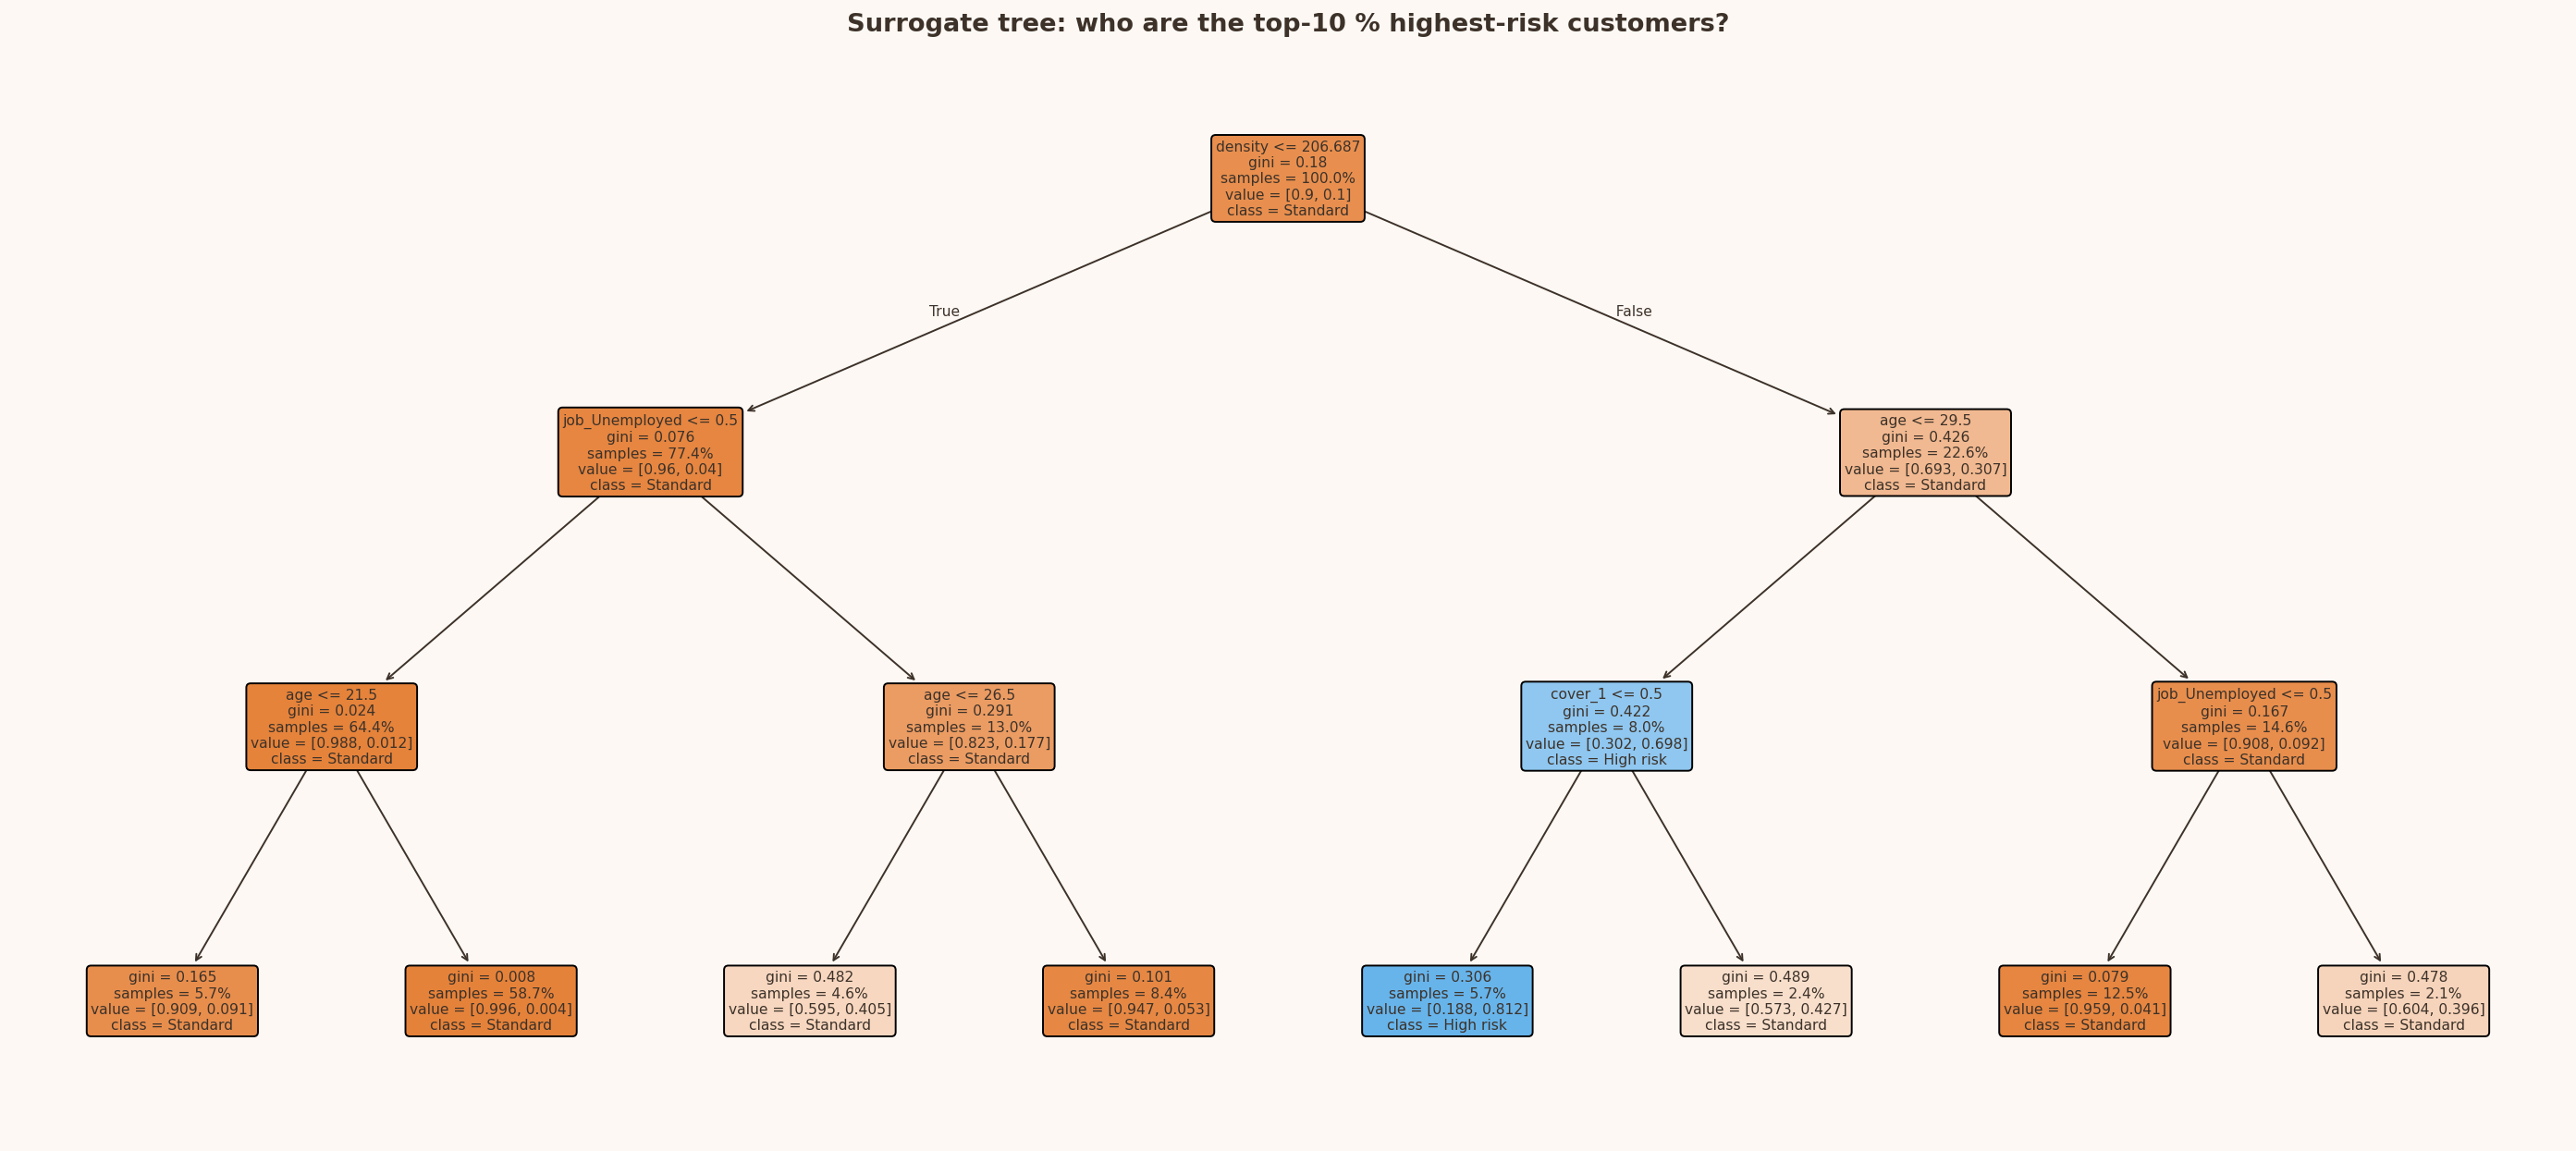

In [34]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    tree, feature_names=list(tree_X.columns),
    class_names=["Standard", "High risk"],
    filled=True, rounded=True, ax=ax, fontsize=8, proportion=True,
)
ax.set_title("Surrogate tree: who are the top-10 % highest-risk customers?",
             fontsize=14)
fig.tight_layout(); plt.show()

The surrogate tree distils the full GLM ranking into a simple rule set
that management can act on directly. Any policy falling into a "High risk"
leaf deserves an underwriting review.

### 6.5 Factor breakdown across tiers

In [35]:
for f in ["gender", "carType", "carCat", "job", "cover", "uwYear"]:
    print(f"\n--- {f} (% of each tier) ---")
    print(profiling.tier_factor_profile(freq_df, tiers, f))


--- gender (% of each tier) ---
              Female  Male
pure_premium              
Low             41.6  58.4
Medium          30.4  69.6
High            23.4  76.6
Very High       15.5  84.5

--- carType (% of each tier) ---
                 A     B     C     D     E
pure_premium                              
Low           25.7  20.0  14.4  22.1  17.8
Medium        25.2  21.5  13.6  20.5  19.1
High          27.9  23.6  13.8  17.7  16.9
Very High     35.9  26.6  12.8  12.4  12.3

--- carCat (% of each tier) ---
              Small  Medium  Large
pure_premium                      
Low            22.8    36.4   40.8
Medium         36.3    37.1   26.6
High           41.5    36.6   21.9
Very High      42.6    37.5   19.9

--- job (% of each tier) ---
              Employed  Housewife  Retired  Self-employed  Unemployed
pure_premium                                                         
Low               29.5       24.5     15.8           23.6         6.6
Medium            39.3       2

### 6.6 Tier x Quadrant cross-tabulation

In [36]:
pp_df["tier"] = tiers.values
tier_quad = pd.crosstab(
    pp_df["tier"], pp_df["quadrant"], normalize="index",
) * 100
print("What quadrant do policies in each tier fall into (%):")
print(tier_quad.round(1).to_string())

What quadrant do policies in each tier fall into (%):
quadrant   Low freq / Low sev  High freq / Low sev  Low freq / High sev  High freq / High sev
tier                                                                                         
Low                      67.8                 12.4                 19.9                   0.0
Medium                    0.8                 32.2                 19.0                  47.9
High                      0.0                  0.1                  1.4                  98.5
Very High                 0.0                  0.0                  0.2                  99.8


In [37]:
top_profile = profiling.describe_top_segment(
    freq_df, pp_df, tiers, segment_label="Very High",
)
print(f"\n{'=' * 60}")
print(f"VERY HIGH TIER PROFILE (top 5%)")
print(f"{'=' * 60}")
print(f"  Policies:            {top_profile['n_policies']:,}")
print(f"  Share of portfolio:  {top_profile['share_of_portfolio_pct']:.1f}%")
print(f"  Mean expected loss:  {top_profile['mean_pure_premium']:.0f} EUR")
print(f"  Risk Index:          {top_profile['ratio_to_overall_mean']:.1f}x")
print(f"\n  Typical profile:")
for k, v in top_profile["typical_profile"].items():
    print(f"    {k:>10s}: {v}")


VERY HIGH TIER PROFILE (top 5%)
  Policies:            1,239
  Share of portfolio:  5.0%
  Mean expected loss:  1029 EUR
  Risk Index:          2.4x

  Typical profile:
        uwYear: 2010 (61%)
        gender: Male (85%)
       carType: A (36%)
        carCat: Small (43%)
           job: Unemployed (63%)
         cover: 0 (88%)
           age: 23.4
        nYears: 4.0
        carVal: 18029.4
       density: 236.9


---
## 7. Conclusions & Recommendations

### 7.1 Executive summary

We estimated the **expected technical loss** for every policy in the motor
portfolio using a two-part actuarial model: a logistic GLM for claim
frequency and a Gamma GLM for claim severity. The combined model is
well-calibrated (predicted/observed ~ 1.00) and validated through
common-cell calibration, year-stability analysis, and a gradient-boosting
challenger.

### 7.2 What "unprofitable" means in this analysis

Without premium data, true profitability cannot be measured. We identify
customers with the **highest expected technical loss** — those most likely
to be underpriced at current rates. This is the standard actuarial proxy
for commercial risk and the most defensible definition given the data.

### 7.3 Key findings

1. **Risk is concentrated:** the top 5 % of policies account for ~12 % of
   total expected loss, at ~2.4x the portfolio average.

2. **Typical high-risk profile:** young (~23 yr), male, unemployed, urban,
   no MD cover — predominantly in the High freq / High sev quadrant.

3. **Frequency and severity tell different stories:**
   - Young unemployed -> high frequency AND high severity
   - Retired -> low frequency but high severity when they do claim
   - Car type E -> increases frequency but decreases severity
   - This is why the quadrant decomposition matters for action design.

4. **Models are robust:** stable across underwriting years, insensitive to
   gender exclusion, and confirmed by a gradient-boosting challenger.

### 7.4 Renewal action matrix

| Risk group | Share | Risk Index | Primary action |
|---|---|---|---|
| Very High (top 5 %) | 5 % | ~2.4x | Strong repricing, strict UW, non-renewal review |
| High (80–95th pctl) | 15 % | ~1.7x | Moderate repricing, deductible adjustment |
| Medium (50–80th) | 30 % | ~1.1x | Monitor, selective repricing |
| Low (bottom 50 %) | 50 % | ~0.6x | Retain, standard renewal |

### 7.5 Caveats & limitations

- **No premium data** — we rank by expected loss, not loss ratio. Adding
  premiums would sharpen the analysis immediately.
- **No individual linkage** — frequency and severity modelled on separate
  datasets. Residual dependence beyond shared covariates is not captured.
- **Gender & EU law** — the Test-Achats ruling (2012) requires unisex
  pricing for new EU contracts. Gender was used diagnostically only;
  the gender-free model performs comparably.
- **~50 % claim rate** — if the dataset is balanced/sampled, absolute
  probabilities require recalibration before deployment.
- **Severity tail** — GLMs are known to underpredict extreme claims.
  The gradient-boosting challenger improves tail ranking.

---
*Generated by the v3 analysis pipeline. Primary model: two-part GLM.
Challenger: gradient-boosted trees. All code in `src/` and this notebook.*